# 05 - Predictive Layer
**Goal:** Train a classifier to predict which segment a new customer belongs to, based on their RFM values.
This transforms our static segmentation into a **deployable, real-time tool**.

| Step | Description |
|------|-------------|
| 1 | Load final segmented RFM data |
| 2 | Train/test split |
| 3 | Train Random Forest classifier |
| 4 | Evaluate — accuracy, classification report, confusion matrix |
| 5 | Feature importance |
| 6 | Save model for deployment |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import joblib
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print("Libraries loaded ✓")

Libraries loaded ✓


## 1. Load Data

In [2]:
rfm = pd.read_csv('../data/processed/rfm_final.csv')

print(f"Shape: {rfm.shape}")
print(f"Segment distribution:\n{rfm['Segment'].value_counts()}")

Shape: (5862, 8)
Segment distribution:
Segment
Lost               1966
At Risk            1458
New & Promising    1249
Champions          1189
Name: count, dtype: int64


## 2. Define Features & Target

In [3]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Segment']

print(f"Features: {X.columns.tolist()}")
print(f"Target classes: {y.unique().tolist()}")
print(f"Class distribution:\n{y.value_counts()}")

Features: ['Recency', 'Frequency', 'Monetary']
Target classes: ['Champions', 'At Risk', 'New & Promising', 'Lost']
Class distribution:
Segment
Lost               1966
At Risk            1458
New & Promising    1249
Champions          1189
Name: count, dtype: int64


## 3. Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")

Train size: 4689
Test size:  1173

Train class distribution:
Segment
Lost               1573
At Risk            1166
New & Promising     999
Champions           951
Name: count, dtype: int64


## 4. Train Random Forest Classifier

In [5]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9923

Classification Report:

                 precision    recall  f1-score   support

        At Risk       0.99      0.99      0.99       292
      Champions       1.00      1.00      1.00       238
           Lost       0.99      0.99      0.99       393
New & Promising       0.98      0.99      0.99       250

       accuracy                           0.99      1173
      macro avg       0.99      0.99      0.99      1173
   weighted avg       0.99      0.99      0.99      1173



### Insight
- **99.23% accuracy** — the classifier almost perfectly learns the K-Means cluster boundaries
- Note: high accuracy is expected since labels were derived from the same RFM features — this is not overfitting but rather boundary learning
- In production, this model would assign new customers to segments in real-time without needing to re-run K-Means on the full dataset

## 5. Confusion Matrix

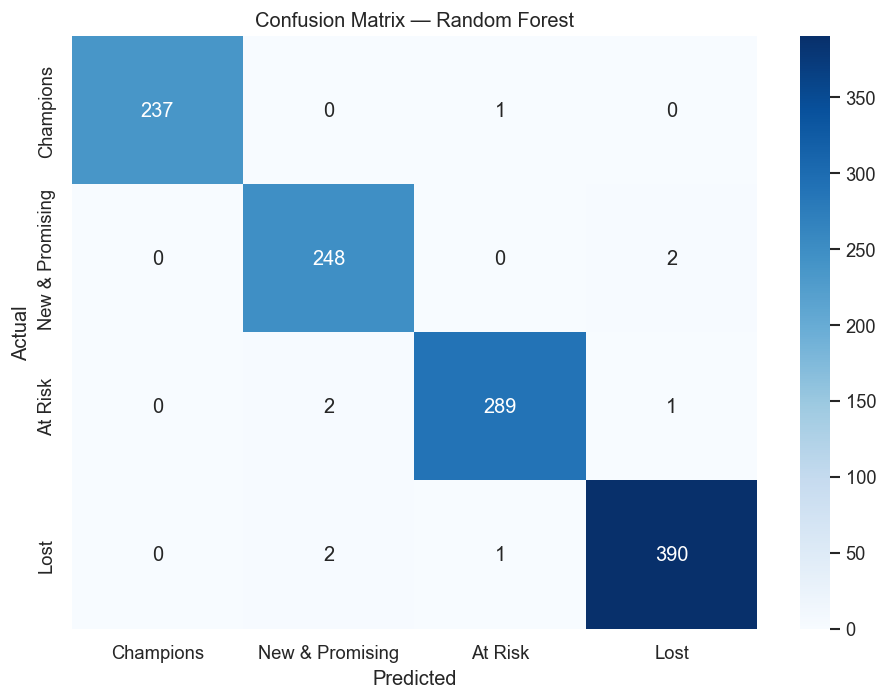

In [6]:
cm = confusion_matrix(y_test, y_pred, 
                      labels=['Champions', 'New & Promising', 'At Risk', 'Lost'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Champions', 'New & Promising', 'At Risk', 'Lost'],
            yticklabels=['Champions', 'New & Promising', 'At Risk', 'Lost'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix.png')
plt.show()

## 6. Cross Validation

In [7]:
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')

print(f"CV Scores: {cv_scores.round(4)}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV Scores: [0.9778 0.9838 0.9855 0.977  0.9906]
Mean CV Accuracy: 0.9829 ± 0.0051


## 7. Feature Importance

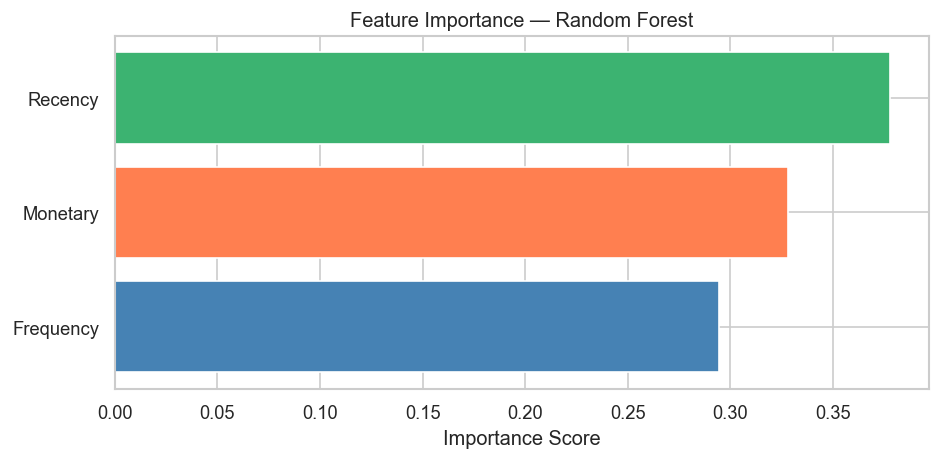

     Feature  Importance
1  Frequency    0.294267
2   Monetary    0.327903
0    Recency    0.377831


In [8]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(importance['Feature'], importance['Importance'], 
         color=['steelblue', 'coral', 'mediumseagreen'], edgecolor='white')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png')
plt.show()

print(importance)

### Insight
- **Confusion matrix is nearly perfect** — only 9 misclassifications out of 1,173 test samples
- **CV accuracy: 98.29% ± 0.51%** — highly stable, model generalises well across folds
- **Recency is the most important feature (0.378)** — when a customer last purchased is the strongest signal for segment membership
- All three features contribute roughly equally — validating that RFM as a whole is a strong feature set

## 8. Save Model

In [9]:
joblib.dump(rf, '../models/segment_classifier.pkl')
print("Model saved to models/segment_classifier.pkl ✓")

Model saved to models/segment_classifier.pkl ✓


## 9. Predict Segment for a New Customer
Demonstrating how the model can be used in production to classify new customers in real time.

In [10]:
# Example new customers
new_customers = pd.DataFrame({
    'Recency':   [10,  400,  25,  250],
    'Frequency': [15,    1,   2,    5],
    'Monetary':  [8000, 200, 500, 1500]
})

new_customers['Predicted_Segment'] = rf.predict(new_customers)
print(new_customers)

   Recency  Frequency  Monetary Predicted_Segment
0       10         15      8000         Champions
1      400          1       200              Lost
2       25          2       500   New & Promising
3      250          5      1500           At Risk


## 10. Project Summary

This notebook completes the end-to-end customer segmentation pipeline:

| Notebook | Description | Key Output |
|----------|-------------|------------|
| 01 | EDA & Cleaning | 776,941 clean transactions |
| 02 | RFM Feature Engineering | 5,862 customer RFM profiles |
| 03 | Classical Clustering | K-Means K=4 selected |
| 04 | Segment Profiling | 4 named business segments |
| 05 | Predictive Layer | 99.23% accuracy classifier |

### Business Impact
- **Champions (20.3%)** → Retain and reward
- **New & Promising (21.3%)** → Nurture and convert
- **At Risk (24.9%)** → Win-back campaigns
- **Lost (33.5%)** → Minimal spend, learn and move on